# NB2 - Reflexion: Reflection is the Gradient

**Workshop: Self-Evolving Agents by Optimizing the Harness (no GPU)**

In NB1 we built the reward signal **V** and a frozen-brain baseline. Now we make
the agent *learn* - with **zero weight updates**. The mechanism is **Reflexion**
(Shinn et al.): the agent attempts a task, observes feedback, writes a reflection
in natural language, and uses it on the next attempt.

In harness terms (H = E, T, C, **S**, L, **V**) we are evolving:
- **C (context)** - we inject reflections / lessons into the prompt, and
- **S (state store)** - we persist those lessons across tasks.

Two experiments:
- **A. Within-task self-repair** - use *execution feedback* (no gold) to fix a
  query on the fly. This is online, test-time self-correction.
- **B. Cross-task reflection memory** - use *train labels* to distill general
  lessons, store them, and carry them into future (test) questions. This is the
  agent getting permanently better. It directly previews the **skill library**
  of NB3-NB5.

In [1]:
import sys, os, json
sys.path.insert(0, os.path.abspath(".."))
from workshop_utils import (
    build_db, load_tasks, run_sql, score_sql, evaluate,
    llm, METER, SCHEMA_TEXT, extract_sql, baseline_prompt, make_baseline_agent,
)
build_db()
baseline_agent = make_baseline_agent()

# Recap the NB1 baseline number (recompute if NB1 wasn't run).
try:
    baseline_acc = json.load(open("../data/baseline_test.json"))["accuracy"]
except FileNotFoundError:
    baseline_acc = evaluate(baseline_agent, split="test")["accuracy"]
print("baseline test accuracy:", round(baseline_acc, 3))

baseline test accuracy: 0.75


## Experiment A - Within-task self-repair (execution feedback)

At *test time* we do not have the gold answer. But the **environment** still
gives feedback for free: does the query run? does it error? does it return rows?
The agent reflects on that signal and revises - up to `max_tries` times.

> Reward used here is a weak proxy: "executes AND returns >=1 row". It reliably
> fixes syntax errors, wrong column names, and broken joins. It can't catch a
> query that runs but is subtly wrong - that needs a real label (Experiment B).

In [2]:
REFLECT_SYS = (
    "You are a meticulous SQLite debugging expert. You diagnose why a query "
    "failed and produce a corrected query."
)

def reflect_and_fix(question, sql, feedback):
    msgs = [
        {"role": "system", "content": REFLECT_SYS},
        {"role": "user", "content":
            "Database schema:\n" + SCHEMA_TEXT +
            "\nQuestion: " + question +
            "\n\nThis SQL was attempted:\n" + sql +
            "\n\nThe environment reported: " + feedback +
            "\n\nFirst explain the likely cause in one sentence. "
            "Then output a corrected SQLite query in a ```sql code block."},
    ]
    return llm(msgs)

def repair_agent(question, max_tries=3):
    sql = extract_sql(llm(baseline_prompt(question)))
    for _ in range(max_tries):
        rows, err = run_sql(sql)
        ok = (err is None) and (len(rows) > 0)
        if ok:
            return sql
        feedback = err if err else "Query executed but returned 0 rows; a filter or join is probably wrong."
        sql = extract_sql(reflect_and_fix(question, sql, feedback))
    return sql

In [3]:
METER.reset()
repair = evaluate(repair_agent, split="test", verbose=True)
print()
print("baseline:", round(baseline_acc, 3), " ->  self-repair:", round(repair["accuracy"], 3))
print(METER)

  OK  [easy  ] # 3  Show all product names in the Electronics category.
  OK  [easy  ] # 5  List all distinct cities where customers live.
  OK  [easy  ] # 8  List the names of customers in the Enterprise segment.
  OK  [easy  ] # 9  How many products are in the Books category?
  OK  [medium] #12  What is the average product price per category? Return categ
  XX  [medium] #14  How many orders were placed in each month of 2025? Return th
  OK  [medium] #16  List the names of products that have never been ordered.
  XX  [medium] #18  What is the total quantity ordered for each product? Return 
  OK  [hard  ] #22  Which product generated the most completed revenue? Return o
  OK  [hard  ] #24  Which customer has the highest total completed revenue? Retu
  OK  [hard  ] #27  What is the average order value (average total revenue per o
  XX  [hard  ] #30  What is the most popular product category by total quantity 
  OK  [hard  ] #33  Which products have an average ordered quantity greater t

## Experiment B - Cross-task reflection memory

Self-repair fixes *one* task in the moment, then forgets. To make the agent
*permanently* better, we let it learn from the **train split** (where we DO have
labels) and carry the lessons forward.

Pipeline:
1. Run the baseline on each **train** task.
2. On every failure, distill **one general, reusable lesson** (not specific to
   that question) by comparing the wrong SQL to the gold SQL.
3. Store lessons in memory (**S**) and prepend them to the prompt (**C**).
4. Measure on **test** as the memory grows.

This is Reflexion as *harness evolution*. It is also the seed of the skill
lifecycle (generate -> extract -> consume) we formalize in NB3.

In [4]:
LESSON_SYS = (
    "You distill a single GENERAL, reusable lesson from a SQL mistake. "
    "The lesson must help on FUTURE, different questions - never mention the "
    "specific question or specific values. Keep it to at most two sentences."
)

def distill_lesson(question, wrong_sql, gold_sql):
    msgs = [
        {"role": "system", "content": LESSON_SYS},
        {"role": "user", "content":
            "Schema:\n" + SCHEMA_TEXT +
            "\nQuestion: " + question +
            "\n\nMy incorrect SQL:\n" + wrong_sql +
            "\n\nThe correct SQL:\n" + gold_sql +
            "\n\nWrite ONE general lesson to avoid this class of mistake."},
    ]
    return llm(msgs).strip()

train = [t for t in load_tasks() if t["split"] == "train"]
lessons = []
METER.reset()
for t in train:
    sql = baseline_agent(t["question"])
    if not score_sql(sql, t["gold"]):
        lessons.append(distill_lesson(t["question"], sql, t["gold"]))
print("collected", len(lessons), "lessons from", len(train), "train tasks\n")
for l in lessons[:6]:
    print("-", l)
print("\n", METER)

collected 3 lessons from 24 train tasks

- Always include all non-aggregated columns in the GROUP BY clause to ensure accurate results when using aggregate functions. This practice helps prevent unexpected behavior and ensures that the query adheres to SQL standards.
- Always ensure that you are grouping and aggregating data based on the correct dimensions and formats, as mismatches can lead to incorrect results or unexpected behavior in your queries. Additionally, be cautious with date formats and ensure consistency in how you extract and manipulate date components.
- When using aggregate functions with `GROUP BY`, ensure that any filtering conditions are applied correctly to the grouped results, rather than prematurely in the main query. Always consider the order of operations in SQL to avoid miscounting or misgrouping data.

 [cost meter] calls=27  in_tok=7,315  out_tok=1,018  ~$0.0017


In [5]:
def memory_block(lessons):
    if not lessons:
        return ""
    return ("Lessons learned from past mistakes (apply when relevant):\n" +
            "\n".join("- " + l for l in lessons))

def make_memory_agent(lessons):
    block = memory_block(lessons)
    def agent_fn(q):
        return extract_sql(llm(baseline_prompt(q, extra=block)))
    return agent_fn

# Measure test accuracy as the memory grows: this is the "learning curve".
checkpoints = sorted(set([0, len(lessons) // 3, 2 * len(lessons) // 3, len(lessons)]))
curve = []
METER.reset()
for k in checkpoints:
    acc = evaluate(make_memory_agent(lessons[:k]), split="test")["accuracy"]
    curve.append((k, acc))
    print("lessons in memory = %2d   test accuracy = %.3f" % (k, acc))
print("\n", METER)

lessons in memory =  0   test accuracy = 0.750
lessons in memory =  1   test accuracy = 0.812
lessons in memory =  2   test accuracy = 0.812
lessons in memory =  3   test accuracy = 0.812

 [cost meter] calls=64  in_tok=21,316  out_tok=2,901  ~$0.0049


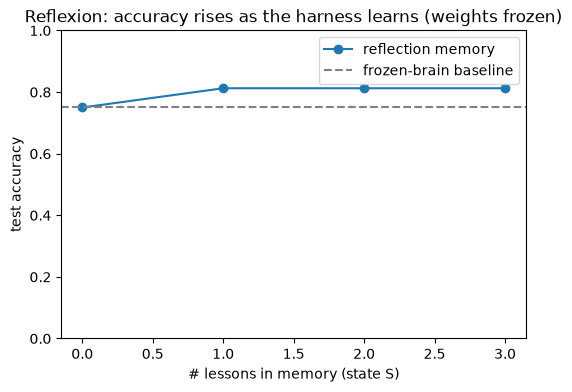

In [8]:
import matplotlib.pyplot as plt
xs = [c[0] for c in curve]
ys = [c[1] for c in curve]
plt.figure(figsize=(6, 4))
plt.plot(xs, ys, marker="o", label="reflection memory")
plt.axhline(baseline_acc, ls="--", color="gray", label="frozen-brain baseline")
plt.xlabel("# lessons in memory (state S)")
plt.ylabel("test accuracy")
plt.title("Reflexion: accuracy rises as the harness learns (weights frozen)")
plt.ylim(0, 1)
plt.legend()
plt.show()

## Failure mode - memory pollution

Self-evolution is not free of risk. A bad or over-general lesson can *lower*
accuracy. The Microsoft/Fudan study (NB3) found **25% of skill pairings actually
degrade performance**. Here we inject a plausible-but-harmful lesson and watch
the number drop - motivating the **validation gates** of SkillOpt (NB4).

In [9]:
bad_lessons = ["To be safe, always add LIMIT 1 to every query.",
               "Always wrap every aggregate in a subquery."]
polluted = evaluate(make_memory_agent(lessons + bad_lessons * 2), split="test")["accuracy"]
print("clean memory:", round(curve[-1][1], 3), " ->  polluted memory:", round(polluted, 3))

clean memory: 0.812  ->  polluted memory: 0.25


## Takeaways

- **Reflection is the gradient.** The agent improved on held-out test with zero
  weight updates - only the harness (context **C** + state **S**) changed.
- Two regimes: *online self-repair* (execution feedback, no labels) and
  *cross-task memory* (train labels distilled into reusable lessons).
- Self-evolution can go **backwards** (memory pollution). You need a gate.

### The gap this leaves (-> NB3, NB4)
These lessons are **unstructured free text** and **unvalidated**. The skill-
optimization papers fix exactly this:
- **NB3 (skill lifecycle):** turn raw experience into *structured* skills, and
  learn the 25%-degrade trap + the 3-dimension meta-skill rubric.
- **NB4 (SkillOpt):** treat the skill document as a *trainable parameter* with a
  learning rate, **validation gate**, and momentum - so memory can't pollute.

### Exercise
1. Change `max_tries` in `repair_agent` to 1 and 5. Plot accuracy vs. cost.
2. Make `distill_lesson` produce lessons WITHOUT seeing the gold SQL (only the
   execution error). Are the lessons still useful? Why / why not?